# BB84 Quantum Key Distribution

## Lecture 7

### What you have already seen
1. Superposition, measurement, and incompatible bases
2. Entanglement and teleportation
3. Simon, QFT, QPE, Shor, Grover, and QAE

### Today
1. Why key distribution is different from encryption
2. The BB84 protocol
3. How eavesdropping shows up as detectable errors
4. Qiskit simulation of BB84 with and without Eve

In [1]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram

np.set_printoptions(precision=3, suppress=True)

rng = np.random.default_rng(7)

# The Cryptography Problem

Suppose Alice wants to send Bob a secret message.

If Alice and Bob already share a secret random key, they can use symmetric encryption.

The cleanest example is the **one-time pad**.

The message is a bit string $m$.

The key is a random bit string $k$ of the same length.

Alice encrypts by XORing the message and key:

$$c=m\oplus k.$$

Bob decrypts by XORing the same key again:

$$c\oplus k=(m\oplus k)\oplus k=m.$$

## One-time pad example

Suppose Alice wants to send

$$m=101100.$$

Alice and Bob already share the random key

$$k=011010.$$

Alice sends the ciphertext

$$c=m\oplus k=101100\oplus 011010=110110.$$

Bob decrypts:

$$c\oplus k=110110\oplus 011010=101100=m.$$

Someone who sees only $c$ cannot tell whether the message was $101100$, $000000$, or anything else, because a different key could explain each possibility.

But this security requires the key to be random, secret, used only once, and as long as the message. **How do Alice and Bob get the shared secret key in the first place?**

## Quantum Key Distribution (QKD)

The one-time pad is secure **if** Alice and Bob already share a secret key.

BB84 is a QKD protocol:

$$\text{quantum channel + public discussion}\longrightarrow\text{shared secret key}.$$

After BB84, Alice and Bob can use that key in a one-time pad or in another symmetric cryptographic system.

BB84 is not a "quantum encryption" protocol (the one-time pad is). It is a secret-key establishment, or key distribution, protocol.

## Public and private channels

BB84 assumes:

1. Alice can send qubits to Bob over a quantum channel.
2. Alice and Bob can talk over a public classical channel.
3. Eve can listen to the public classical channel.
4. Eve may also interact with the quantum channel.

Important caveat:

The public classical channel must be **authenticated**.

Otherwise Eve could impersonate Alice to Bob and Bob to Alice, creating a man-in-the-middle attack.

# The Four BB84 States

BB84 uses two bases.

The computational, or $Z$, basis:

$$|0\rangle,\qquad |1\rangle.$$

The Hadamard, or $X$, basis:

$$|+\rangle=\frac{|0\rangle+|1\rangle}{\sqrt2},$$

$$|-\rangle=\frac{|0\rangle-|1\rangle}{\sqrt2}.$$

Alice encodes each classical bit using one of these two bases.

## Encoding table

| Alice bit | Alice basis | Qubit sent |
|---:|:---:|:---:|
| 0 | $Z$ | $\mid 0\rangle$ |
| 1 | $Z$ | $\mid 1\rangle$ |
| 0 | $X$ | $\mid +\rangle$ |
| 1 | $X$ | $\mid -\rangle$ |

The bit is classical.

The basis choice is also classical.

The transmitted object is quantum.

## Why two bases matter

The $Z$ and $X$ bases are incompatible.

If a qubit is prepared in the $Z$ basis and measured in the $Z$ basis, the result is deterministic.

Example:

$$|0\rangle \xrightarrow{Z\text{ measurement}} 0\quad\text{with probability }1.$$

But if the same qubit is measured in the $X$ basis,

$$|0\rangle=\frac{|+\rangle+|-\rangle}{\sqrt2},$$

so

$$\Pr(+)=\frac12,\qquad \Pr(-)=\frac12.$$

A wrong-basis measurement produces a random answer and disturbs the state.

## The same calculation the other way

If Alice sends $|+\rangle$ and Bob measures in the $Z$ basis:

$$|+\rangle=\frac{|0\rangle+|1\rangle}{\sqrt2}.$$

So

$$\Pr(0)=\left|\frac{1}{\sqrt2}\right|^2=\frac12,$$

and

$$\Pr(1)=\left|\frac{1}{\sqrt2}\right|^2=\frac12.$$

The bit value is only reliable when Alice and Bob use the same basis.

# BB84 Protocol: High-Level Steps

1. Alice randomly chooses bits.
2. Alice randomly chooses bases.
3. Alice prepares and sends one qubit per bit.
4. Bob randomly chooses measurement bases.
5. Bob measures each qubit.
6. Alice and Bob publicly compare bases, not bit values.
7. They keep only positions where the bases matched.
8. They test a random subset of measured bits for errors.
9. If the error rate is low, they distill a key.

## Step 1: Alice prepares random states

For each position $i$, Alice chooses

$$a_i\in\{0,1\}$$

and

$$b_i\in\{Z,X\}.$$

The state sent is

$$|\psi_i\rangle=\begin{cases}
|0\rangle, & a_i=0,\ b_i=Z,\\
|1\rangle, & a_i=1,\ b_i=Z,\\
|+\rangle, & a_i=0,\ b_i=X,\\
|-\rangle, & a_i=1,\ b_i=X.
\end{cases}$$

Alice does not reveal $a_i$ or $b_i$ before transmission.

## Step 2: Bob measures randomly

For each received qubit, Bob chooses

$$c_i\in\{Z,X\}.$$

If $c_i=b_i$, Bob measures in the correct basis, so ideally

$$\text{Bob's bit}=a_i.$$

If $c_i\ne b_i$, Bob measures in the wrong basis, so his bit is random:

$$\Pr(\text{Bob's bit}=a_i)=\frac12.$$

These wrong-basis positions will be discarded later.

## Step 3: Basis sifting

After all qubits are transmitted, Alice and Bob use the public classical channel.

They announce only their bases:

$$b_1,b_2,\ldots,b_n$$

and

$$c_1,c_2,\ldots,c_n.$$

They keep positions where

$$b_i=c_i.$$

Since each basis is chosen uniformly at random,

$$\Pr(b_i=c_i)=\frac12.$$

So about half the transmitted qubits survive sifting.

## Why announcing bases does not reveal the key

Alice and Bob reveal the bases only **after** Bob has measured.

For a kept position, Eve hears something like:

> Alice used $Z$, Bob used $Z$.

But the key bit could still be $0$ or $1$.

The basis information tells Eve which measurement would have been correct. It does not tell Eve what the outcome was.

# Detecting Eve

Consider the simplest attack: intercept-resend.

For each qubit:

1. Eve chooses a random basis.
2. Eve measures the qubit.
3. Eve sends Bob a new qubit consistent with her result.

If Eve chooses the same basis as Alice, she introduces no error.

If Eve chooses the wrong basis, her result is random and the state she resends may disagree with Alice's original state.

## Error rate from intercept-resend

Focus only on positions Alice and Bob keep, so Alice and Bob used the same basis.

Eve chooses the wrong basis with probability

$$\frac12.$$

Given Eve chose the wrong basis, her measurement result is random.

She resends a state in the wrong basis.

When Bob measures in Alice's correct basis, Bob disagrees with Alice with probability

$$\frac12.$$

Therefore the error probability on sifted bits is

$$\frac12\cdot\frac12=\frac14.$$

So intercept-resend creates about a **25% quantum bit error rate** on the sifted key.

## Quantum bit error rate (QBER)

After sifting, Alice and Bob choose a random subset of the sifted bits and publicly compare those bit values.

The observed error rate is called the quantum bit error rate:

$$\text{QBER}=\frac{\#\text{ disagreements}}{\#\text{ tested sifted bits}}.$$

If QBER is too high, they abort.

If QBER is low, they discard the tested bits and continue with the remaining bits.

## Why this is quantum

Classically, Eve could copy a signal and look at it later. Quantumly, unknown states cannot be copied perfectly. This is the no-cloning theorem.

BB84 uses two additional facts:

1. Measuring in the wrong basis creates random outcomes.
2. Measurement collapses the quantum state onto a classical bit value.

These two facts make Eve detectable.

# After the Quantum Part

A real QKD protocol does more than sifting.

After estimating QBER, Alice and Bob do:

1. **Error correction:** reconcile small differences in their sifted keys.
2. **Privacy amplification:** compress the reconciled key to reduce Eve's possible information.

## Privacy amplification intuition

Privacy amplification happens **after reconciliation and error correction**. At this point Alice and Bob should share the same reconciled string:

$$x_A=x_B=x.$$

Eve may still know partial information about $x$.

Alice and Bob publicly choose a hash function

$$h:\{0,1\}^r\to\{0,1\}^\ell,$$

where

$$\ell<r.$$

They both compute

$$K=h(x).$$

Because Alice and Bob use the same input $x$, they get the same final key $K$. Compression sacrifices key length to reduce Eve's information about the final key.

## Hashing Decorrelates Key Information

Eve is allowed to know the hash function. She can compute

$$h(x')$$

for every raw-key candidate $x'$ that is still possible from her point of view.

Privacy amplification works only if Eve still has many possible candidates for Alice and Bob's reconciled string $x$.

Example:

- Alice and Bob share a reconciled 1000-bit string $x$.
- Eve's quantum attack plus public error correction may have leaked about 300 bits of information.
- Eve still has roughly 700 bits of uncertainty about $x$.

Alice and Bob should not keep all 1000 bits. They might choose a public universal hash function

$$h:\{0,1\}^{1000}\to\{0,1\}^{500}.$$

The final key is

$$K=h(x).$$

Eve can hash all her candidates, but many candidates still remain possible. The 500-bit output can (and should) be close to uniform from Eve's perspective.

# Qiskit Simulation

We will simulate BB84 in two layers.

First, show individual prepare-and-measure circuits.

Then, run many random BB84 trials and compare:

1. no eavesdropper,
2. intercept-resend Eve.

In [2]:
def prepare_bb84_state(bit, basis):
    qc = QuantumCircuit(1)
    if bit == 1:
        qc.x(0)
    if basis == 'X':
        qc.h(0)
    return qc


def measurement_probabilities(bit, prep_basis, measure_basis):
    qc = prepare_bb84_state(bit, prep_basis)
    if measure_basis == 'X':
        qc.h(0)
    state = Statevector.from_instruction(qc)
    probs = state.probabilities_dict()
    return {str(k): float(v) for k, v in probs.items()}


examples = [
    (0, 'Z', 'Z'),
    (0, 'Z', 'X'),
    (1, 'X', 'X'),
    (1, 'X', 'Z'),
]

for bit, prep_basis, measure_basis in examples:
    print(f'Alice bit={bit}, Alice basis={prep_basis}, Bob basis={measure_basis}:',
          measurement_probabilities(bit, prep_basis, measure_basis))

Alice bit=0, Alice basis=Z, Bob basis=Z: {'0': 1.0}
Alice bit=0, Alice basis=Z, Bob basis=X: {'0': 0.4999999999999999, '1': 0.4999999999999999}
Alice bit=1, Alice basis=X, Bob basis=X: {'1': 0.9999999999999996}
Alice bit=1, Alice basis=X, Bob basis=Z: {'0': 0.4999999999999999, '1': 0.4999999999999999}


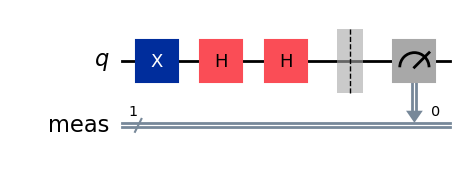

In [ ]:
demo_qc = prepare_bb84_state(bit=1, basis='X') # Alice prepares 1 in the X basis: |+> state.
demo_qc.h(0)  # Bob measures in X by rotating X basis back to Z basis.
demo_qc.measure_all()
demo_qc.draw(output='mpl')

## Reading the one-qubit simulation

When Alice and Bob use the same basis, the outcome is deterministic.

Examples:

$$|0\rangle\text{ measured in }Z\Rightarrow 0,$$

$$|-\rangle\text{ measured in }X\Rightarrow 1.$$

When the bases differ, Qiskit shows probabilities close to

$$\{0:1/2,\ 1:1/2\}.$$

That is the whole security mechanism in miniature.

# Simulating the Full BB84 Protocol

For each transmitted qubit, we randomly choose:

1. Alice's bit,
2. Alice's basis,
3. Bob's basis,
4. optionally Eve's basis.

The simulation records:

1. how many bits survive sifting,
2. the QBER on sifted bits,
3. the first few bits of Alice and Bob's sifted keys.

In [4]:
def sample_from_probs(probs, rng):
    labels = np.array(list(probs.keys()))
    values = np.array(list(probs.values()), dtype=float)
    values = values / values.sum()
    return int(rng.choice(labels, p=values))


def measure_prepared_state(bit, prep_basis, measure_basis, rng):
    probs = measurement_probabilities(bit, prep_basis, measure_basis)
    return sample_from_probs(probs, rng)


def simulate_bb84(num_qubits=200, eve=False, sample_fraction=0.25, seed=0):
    local_rng = np.random.default_rng(seed)
    bases = np.array(['Z', 'X'])

    alice_bits = local_rng.integers(0, 2, size=num_qubits)
    alice_bases = local_rng.choice(bases, size=num_qubits)
    bob_bases = local_rng.choice(bases, size=num_qubits)

    bob_bits = np.empty(num_qubits, dtype=int)
    eve_bases = np.full(num_qubits, '-', dtype='<U1')
    eve_bits = np.full(num_qubits, -1, dtype=int)

    for i in range(num_qubits):
        sent_bit = int(alice_bits[i])
        sent_basis = str(alice_bases[i])

        if eve:
            eve_basis = str(local_rng.choice(bases))
            eve_result = measure_prepared_state(sent_bit, sent_basis, eve_basis, local_rng)
            eve_bases[i] = eve_basis
            eve_bits[i] = eve_result
            # Eve resends the state she thinks she measured.
            sent_bit = eve_result
            sent_basis = eve_basis

        bob_bits[i] = measure_prepared_state(sent_bit, sent_basis, str(bob_bases[i]), local_rng)

    keep_mask = alice_bases == bob_bases
    kept_indices = np.flatnonzero(keep_mask)
    alice_sifted = alice_bits[keep_mask]
    bob_sifted = bob_bits[keep_mask]

    if len(alice_sifted) > 0:
        disagreements = alice_sifted != bob_sifted
        qber = float(np.mean(disagreements))
    else:
        disagreements = np.array([], dtype=bool)
        qber = np.nan

    test_size = int(np.floor(sample_fraction * len(alice_sifted)))
    if test_size > 0:
        test_positions = local_rng.choice(len(alice_sifted), size=test_size, replace=False)
        sample_qber = float(np.mean(alice_sifted[test_positions] != bob_sifted[test_positions]))
    else:
        test_positions = np.array([], dtype=int)
        sample_qber = np.nan

    return {
        'alice_bits': alice_bits,
        'alice_bases': alice_bases,
        'bob_bases': bob_bases,
        'bob_bits': bob_bits,
        'eve_bases': eve_bases,
        'eve_bits': eve_bits,
        'keep_mask': keep_mask,
        'kept_indices': kept_indices,
        'alice_sifted': alice_sifted,
        'bob_sifted': bob_sifted,
        'qber': qber,
        'sample_qber': sample_qber,
        'test_positions': test_positions,
    }

In [5]:
no_eve = simulate_bb84(num_qubits=200, eve=False, seed=11)
with_eve = simulate_bb84(num_qubits=200, eve=True, seed=11)

for label, result in [('No Eve', no_eve), ('Intercept-resend Eve', with_eve)]:
    print(label)
    print('  transmitted qubits:', len(result['alice_bits']))
    print('  sifted key length:', len(result['alice_sifted']))
    print('  sifted fraction:', len(result['alice_sifted']) / len(result['alice_bits']))
    print('  full sifted-key QBER:', result['qber'])
    print('  sample QBER:', result['sample_qber'])
    print('  Alice sifted prefix:', ''.join(map(str, result['alice_sifted'][:32])))
    print('  Bob sifted prefix:  ', ''.join(map(str, result['bob_sifted'][:32])))
    print()

No Eve
  transmitted qubits: 200
  sifted key length: 112
  sifted fraction: 0.56
  full sifted-key QBER: 0.0
  sample QBER: 0.0
  Alice sifted prefix: 01010011010011101111101011111101
  Bob sifted prefix:   01010011010011101111101011111101

Intercept-resend Eve
  transmitted qubits: 200
  sifted key length: 112
  sifted fraction: 0.56
  full sifted-key QBER: 0.20535714285714285
  sample QBER: 0.21428571428571427
  Alice sifted prefix: 01010011010011101111101011111101
  Bob sifted prefix:   00000011010001101111100110011101



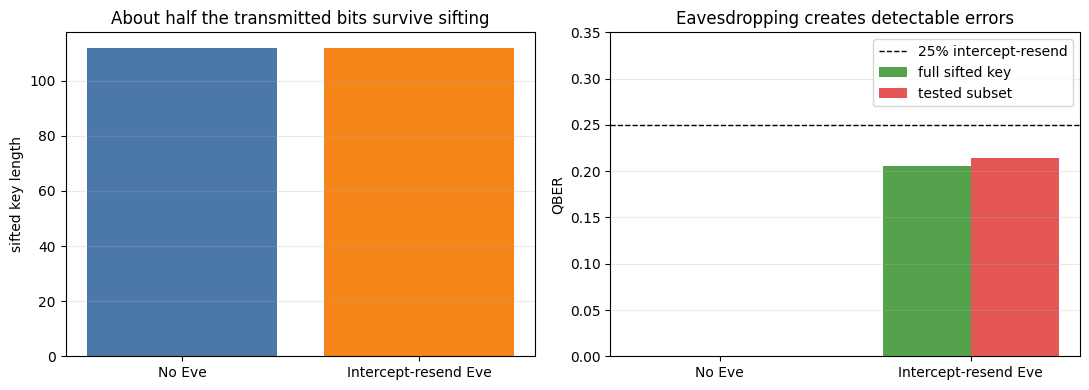

In [6]:
labels = ['No Eve', 'Intercept-resend Eve']
sifted_lengths = [len(no_eve['alice_sifted']), len(with_eve['alice_sifted'])]
qbers = [no_eve['qber'], with_eve['qber']]
sample_qbers = [no_eve['sample_qber'], with_eve['sample_qber']]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(labels, sifted_lengths, color=['#4c78a8', '#f58518'])
axes[0].set_ylabel('sifted key length')
axes[0].set_title('About half the transmitted bits survive sifting')
axes[0].grid(axis='y', alpha=0.25)

x = np.arange(len(labels))
width = 0.35
axes[1].bar(x - width/2, qbers, width, label='full sifted key', color='#54a24b')
axes[1].bar(x + width/2, sample_qbers, width, label='tested subset', color='#e45756')
axes[1].axhline(0.25, color='black', linestyle='--', linewidth=1, label='25% intercept-resend')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_ylim(0, 0.35)
axes[1].set_ylabel('QBER')
axes[1].set_title('Eavesdropping creates detectable errors')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.25)
plt.tight_layout()

## What the BB84 simulation shows

Without Eve, ideal BB84 has essentially zero QBER after sifting.

With intercept-resend Eve, the sifted key has QBER near

$$25\%.$$

# Many-Trial Statistics

A single run is noisy because basis choices and measurement outcomes are random.

To see the pattern, repeat the protocol many times.

We expect:

1. sifted fraction near $1/2$ in both cases,
2. QBER near $0$ with no Eve in the ideal simulation,
3. QBER near $1/4$ with intercept-resend Eve.

In [7]:
def repeat_bb84(num_trials=300, num_qubits=200, eve=False, seed=100):
    qbers = []
    sample_qbers = []
    sifted_fractions = []
    for trial in range(num_trials):
        result = simulate_bb84(num_qubits=num_qubits, eve=eve, seed=seed + trial)
        qbers.append(result['qber'])
        sample_qbers.append(result['sample_qber'])
        sifted_fractions.append(len(result['alice_sifted']) / num_qubits)
    return np.array(qbers), np.array(sample_qbers), np.array(sifted_fractions)

qber_no_eve, sample_no_eve, sift_no_eve = repeat_bb84(eve=False)
qber_eve, sample_eve, sift_eve = repeat_bb84(eve=True)

print('Average sifted fraction, no Eve:', np.mean(sift_no_eve))
print('Average sifted fraction, Eve:', np.mean(sift_eve))
print('Average QBER, no Eve:', np.mean(qber_no_eve))
print('Average QBER, Eve:', np.mean(qber_eve))

Average sifted fraction, no Eve: 0.49673333333333336
Average sifted fraction, Eve: 0.49673333333333336
Average QBER, no Eve: 0.0
Average QBER, Eve: 0.25143231745275063


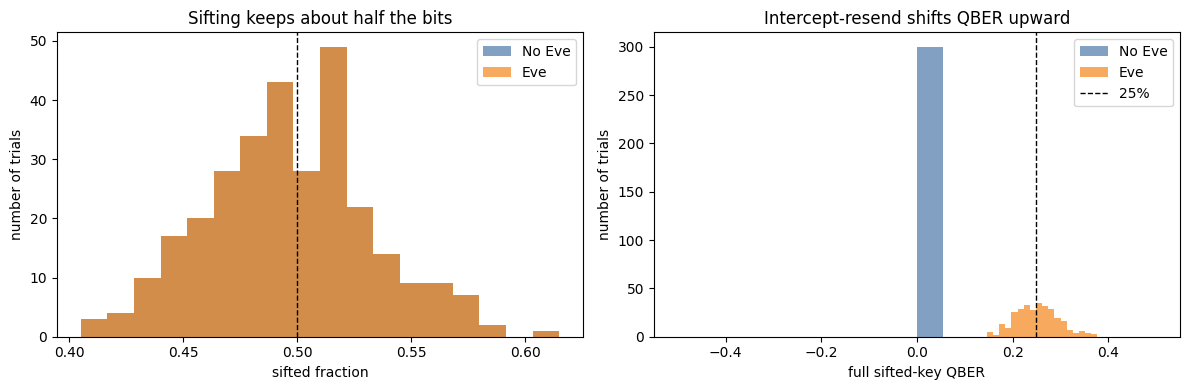

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(sift_no_eve, bins=18, alpha=0.7, label='No Eve', color='#4c78a8')
axes[0].hist(sift_eve, bins=18, alpha=0.7, label='Eve', color='#f58518')
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=1)
axes[0].set_xlabel('sifted fraction')
axes[0].set_ylabel('number of trials')
axes[0].set_title('Sifting keeps about half the bits')
axes[0].legend()

axes[1].hist(qber_no_eve, bins=18, alpha=0.7, label='No Eve', color='#4c78a8')
axes[1].hist(qber_eve, bins=18, alpha=0.7, label='Eve', color='#f58518')
axes[1].axvline(0.25, color='black', linestyle='--', linewidth=1, label='25%')
axes[1].set_xlabel('full sifted-key QBER')
axes[1].set_ylabel('number of trials')
axes[1].set_title('Intercept-resend shifts QBER upward')
axes[1].legend()
plt.tight_layout()

## What about normal noise?

Real devices and channels have noise even without Eve.

So practical BB84 does not abort at the first error.

Instead Alice and Bob estimate whether QBER is below a protocol threshold.

A low QBER can be handled by error correction and privacy amplification.

A high QBER means either the channel is too noisy or someone is interfering.

In both cases, Alice and Bob should not use the raw key directly.

# Handling Noise: Reconciliation

In the ideal simulation, any sifted-key disagreement looked suspicious.

Real quantum channels are not ideal.

Alice and Bob can disagree because of ordinary noise:

1. imperfect state preparation,
2. photon loss and detector errors,
3. measurement misalignment,
4. environmental disturbance.

So practical BB84 separates two tasks:

1. estimate whether the observed QBER is low enough to continue,
2. correct the remaining differences in Alice and Bob's sifted keys.

## Error Correction

Error correction in QKD is classical post-processing on the sifted keys.

Alice and Bob reconcile two classical strings after measurement:

$$x_A\approx x_B.$$

They exchange parity information over the public channel.

For example, Alice may reveal the parity of a block:

$$x_1\oplus x_2\oplus x_3\oplus x_4.$$

Bob compares this with the parity of his block.

If the parities disagree, they know there is an odd number of errors in that block.

## Where CSS codes enter

CSS codes are quantum error-correcting codes built from two classical linear codes.

They are designed to handle two kinds of quantum errors separately:

1. bit-flip errors, like $X$ errors,
2. phase-flip errors, like $Z$ errors.

The Shor-Preskill security proof connects BB84 to an entanglement-based protocol using CSS codes.

For this lecture, the important takeaway is that error correction can be used to correct for noise-driven errors during QKD.

## Noise versus eavesdropping

Alice and Bob cannot always tell whether errors came from Eve or from a noisy device.

If QBER is low enough, error correction reconciles Alice and Bob's strings. If QBER is too high, they abort.

So error-correcting codes help BB84 tolerate noise, but they do not make it safe from arbitrary eavesdropping. They work only below a security threshold.

# Takeaways

BB84 is one of the cleanest examples of quantum information as a resource.

The protocol uses single qubits, random bases, and public classical discussion.

Its power comes from a simple fact:

> Eve cannot learn the basis-dependent states without risking detectable errors.

In the intercept-resend model, Eve creates about 25% QBER on the sifted key.